In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from parameters import *

## Ramp Slope Analysis 

### GOE

In [6]:
dataList = []
dataList.append(np.loadtxt(f"SFF/goe_sff_data,j={j},M={M},N={N},ntraj=1000.dat",dtype=complex))

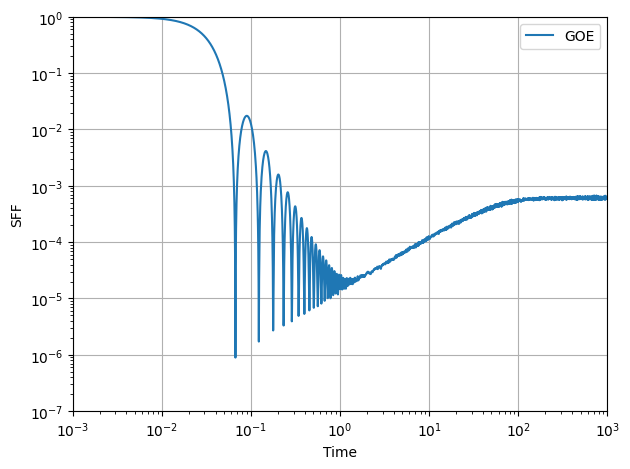

In [19]:
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Time")
plt.ylabel("SFF")
plt.xlim(1e-3,1e3)
plt.ylim(1e-7,1)

# GOE data
data1 = np.loadtxt(f"SFF/goe_sff_data,j={j},M={M},N={N},ntraj=1000.dat",dtype=complex)

# Isolate the ramp
indl = int(2.05e3); indr = int(4e3)
indl = int(2e3); indr = int(3.4e3)
data_ramp_GOE = data1[indl:indr]

# Plot the actual data
data1 = np.column_stack(data1)
plt.plot(data1[0],data1[1],label=f"GOE")

# Plot the ramp
data_ramp_GOE = np.column_stack(data_ramp_GOE)
# plt.plot(data_ramp_GOE[0], data_ramp_GOE[1])

# Plot the fit
# Fit the ramp
m,b = np.polyfit(np.log10(data_ramp_GOE[0]),np.log10(data_ramp_GOE[1]),1)
# print(f"g={round(g_arr[g_ind],2)}, m={round(np.real(m),2)},t={round(np.real(data1[0][indl]),2)}")
# plt.plot(data1[0], 10**b*data1[0]**m,'--',label= f"slope = {round(np.real(m),2)}")
#plt.plot(data[0], 10**b*data[0]**m,'--',label=f"g={np.round(g_arr[g_ind])}, m={round(np.real(m),2)}")

plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('GOE SFF')

## Dicke

In [ ]:
g_arr = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# g_arr = [0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

In [4]:
dataList = []
kappa = kappa_arr[0]
beta = beta_arr[-1]
for g in g_arr:
    dataList1 = []
    for M in M_arr:
        data = np.loadtxt(f"SFF/SFFvsTime,j={j},M={M},g={g},beta={beta},kappa={kappa},ntraj={ntraj}.dat", dtype=complex)
        dataList1.append(data)
    dataList.append(dataList1)

c:\Users\prasa\miniconda3\envs\scicalc\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\prasa\miniconda3\envs\scicalc\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\prasa\AppData\Local\Temp\ipykernel_18004\2325487767.py:44: RuntimeWarning: invalid value encountered in power
  plt.plot(data[0], 10**b*data[0]**m,'--',label= f"slope = {round(np.real(m),2)}")


g=0.1, m=-0.05,t=9.0
g=0.1, m=-0.01,t=9.0
g=0.2, m=-0.03,t=9.0
g=0.2, m=-0.11,t=9.0
g=0.3, m=-0.1,t=9.0
g=0.3, m=-0.1,t=9.0
g=0.4, m=-0.26,t=9.0
g=0.4, m=-0.04,t=9.0
g=0.5, m=0.26,t=9.0
g=0.5, m=0.28,t=9.0
g=0.6, m=0.44,t=5.0
g=0.6, m=2.58,t=5.0
g=0.7, m=6.49,t=5.0
g=0.7, m=6.8,t=5.0
g=0.8, m=7.49,t=3.5
g=0.8, m=7.72,t=3.5
g=0.9, m=10.67,t=3.0
g=0.9, m=10.59,t=3.0
g=1.0, m=14.23,t=3.0
g=1.0, m=14.09,t=3.0


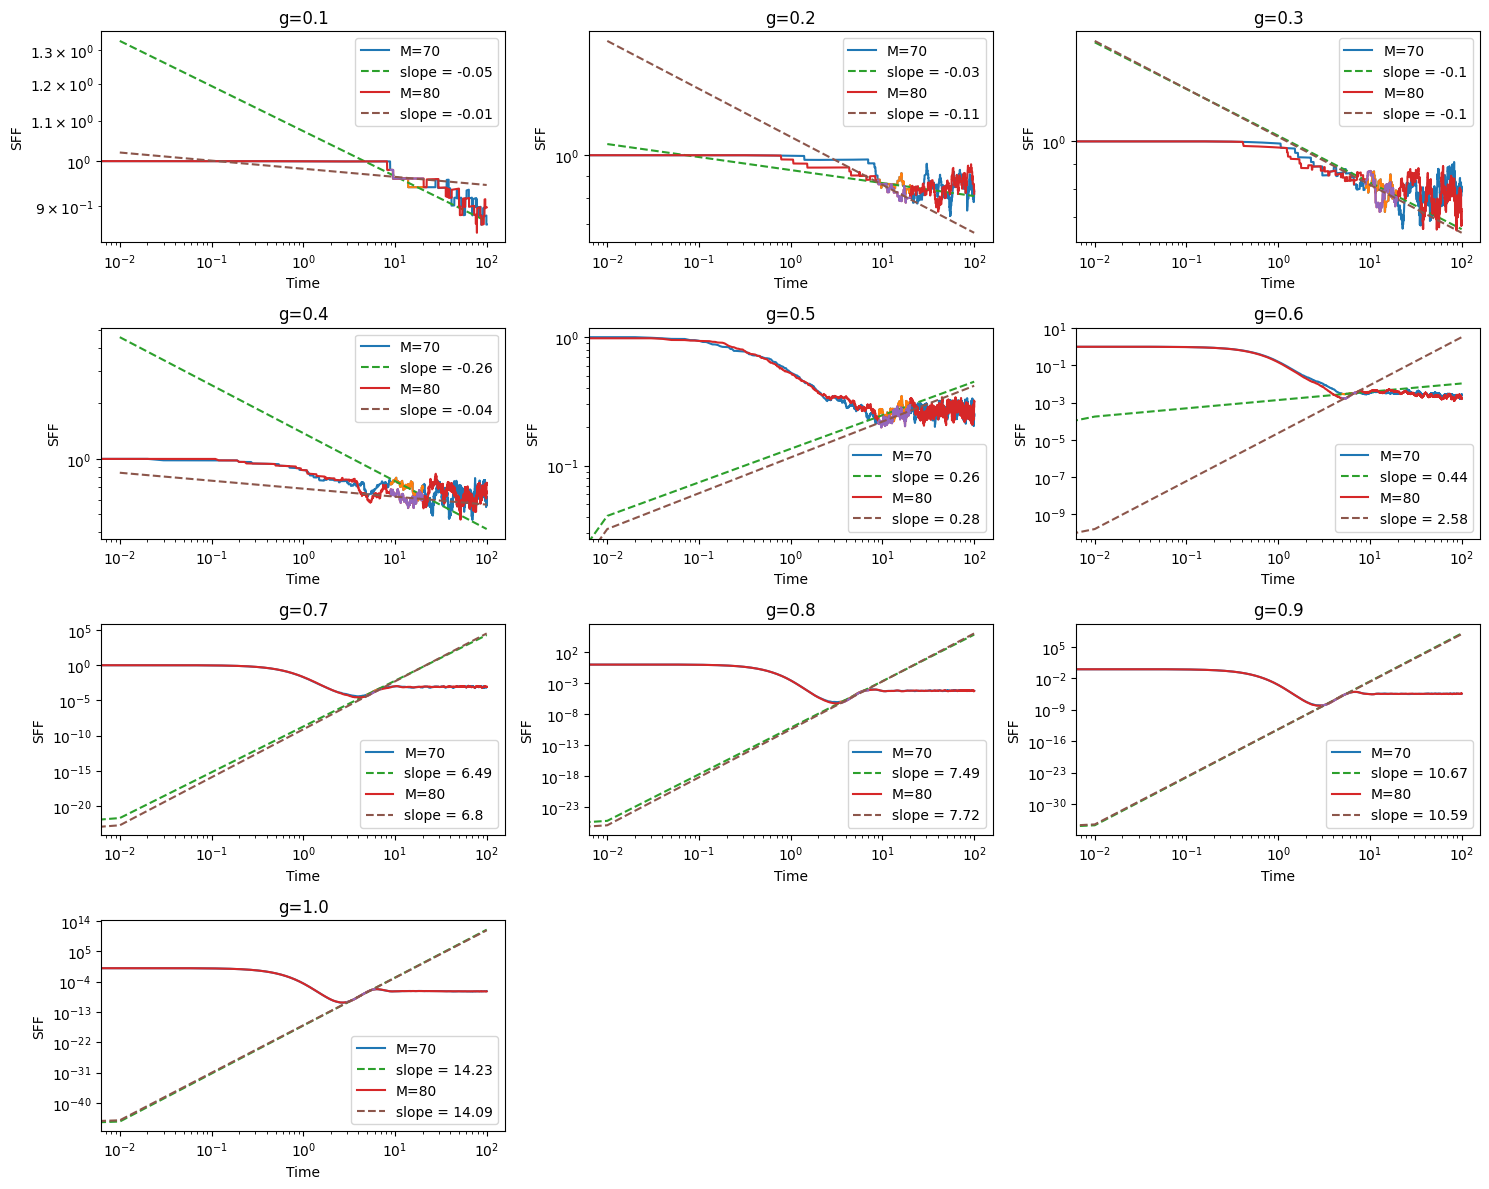

In [7]:
plt.figure(figsize=(15,12))
m_arr_arr = []
for g_ind, dataList1 in enumerate(dataList):
    m_arr = []
    for M_ind, data in enumerate(dataList1):
        #plt.suptitle(f"Dicke Model SFF (j={j}, M={M})")
        plt.subplot(4,3,g_ind+1)
        plt.title(f"g={round(g_arr[g_ind],2)}")
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel("Time")
        plt.ylabel("SFF")
        # plt.xlim(1e-3,1e3)
        # plt.ylim(1e-40,1)
        
        # Isolate the ramp
        indl = int(9e2); indr = int(2e3)

        if g_arr[g_ind] == 0.6:
            indl = int(5e2); indr = int(7e2)
        if g_arr[g_ind] == 0.7:
            indl = int(5e2); indr = int(7e2)
        if g_arr[g_ind] == 0.8:
            indl = int(3.5e2); indr = int(7e2)
        if g_arr[g_ind] == 0.9:
            indl = int(3e2); indr = int(6e2)
        if g_arr[g_ind] == 1.0:
            indl = int(3e2); indr = int(6e2)

        data_ramp = data[indl:indr]

        # Plot the actual data
        data = np.column_stack(data)
        plt.plot(data[0],data[1],label=f"M={M_arr[M_ind]}")

        # Plot the ramp
        data_ramp = np.column_stack(data_ramp)
        plt.plot(data_ramp[0], data_ramp[1])

        # Plot the fit
        # Fit the ramp
        m,b = np.polyfit(np.log10(data_ramp[0]),np.log10(data_ramp[1]),1)
        print(f"g={round(g_arr[g_ind],2)}, m={round(np.real(m),2)},t={round(np.real(data[0][indl]),2)}")
        plt.plot(data[0], 10**b*data[0]**m,'--',label= f"slope = {round(np.real(m),2)}")
        m_arr.append(m)
        plt.tight_layout()
        plt.grid()
    m_arr_arr.append(m_arr)
    plt.legend()
plt.savefig('SFF/Dicke (open) SFF Slope')
plt.show()

c:\Users\prasa\miniconda3\envs\scicalc\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


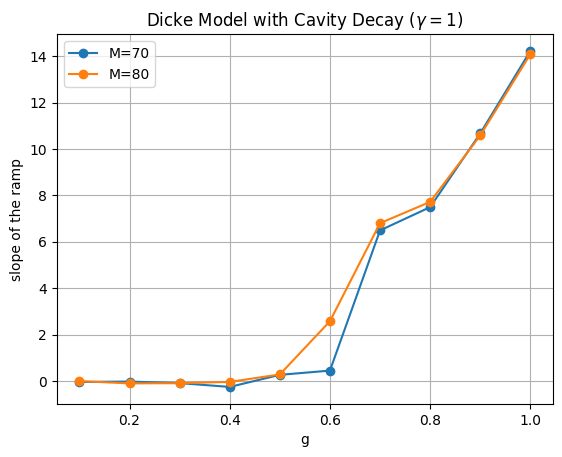

In [15]:
m_arr_arr = np.column_stack(m_arr_arr)
for M_ind, m_arr in enumerate(m_arr_arr):
    plt.title(f"Dicke Model with Cavity Decay "+r"($\gamma=1$)")
    plt.plot(g_arr,m_arr,'-o',label=f'M={M_arr[M_ind]}')
    plt.xlabel('g')
    plt.ylabel('slope of the ramp')
    plt.grid()
plt.legend()
plt.grid()
plt.savefig("plots/ramp slope (open) vs g for different M")
plt.show()